# Task 4: Advanced Statistical Modeling, Forecasting, Segmentation, and Predictive Analytics

A reproducible end-to-end retail analytics pipeline. Execute cells top to bottom.

In [1]:
from pathlib import Path
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.generate_data import save_transactions
from src.statistical_analysis import descriptive_statistics, run_hypothesis_tests
from src.time_series import prepare_weekly_sales, adf_report, forecast_sales, save_decomposition
from src.customer_segmentation import build_rfm, fit_segmentation
from src.predictive_modeling import run_predictive_models
for folder in ['data/processed','figures/statistics','figures/time_series','figures/clustering','figures/predictive','models']:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)
DATA_PATH = ROOT / 'data/processed/customer_transactions_task4.csv'
FIGURES = ROOT / 'figures'
MODELS = ROOT / 'models'


## Section 0: Reproducible Synthetic Data

Generates exactly 2,500 transaction records across 2024-2025 with customer, order, service, rating, and churn fields.

In [2]:
data = save_transactions(DATA_PATH)
print(data.shape, data['Customer_ID'].nunique(), data['Order_Date'].min(), data['Order_Date'].max())
display(data.head())


(2500, 11) 679 2024-01-01 00:00:00 2025-12-31 00:00:00


,Customer_ID,Order_Date,Region,Category,Order_Value,Discount_Pct,Delivery_Days,Recency_Days,Frequency,Churn,Customer_Rating
0,C00619,2024-01-01,West,Home,80.02,9.59,6,67,3,0,4
1,C00490,2024-01-01,North,Home,131.15,19.64,4,30,2,0,4
2,C00180,2024-01-02,West,Home,109.94,1.30,3,62,7,0,3
3,C00054,2024-01-02,East,Fashion,102.24,6.32,3,38,6,0,5
4,C00262,2024-01-03,North,Beauty,50.94,12.49,4,102,8,0,4


## Section 1: Advanced Statistical Analysis

Descriptive moments, Welch two-sample t-test, Region-Churn chi-square, one-way ANOVA, and 95% confidence intervals quantify differences and uncertainty. Reject a null only when p < 0.05.

,Mean,Median,Mode,Variance,Std_Dev,Skewness,Kurtosis
Order_Value,92.953,79.73,38.27,2475.764,49.757,1.513,3.196
Discount_Pct,11.987,11.82,0.00,44.302,6.656,0.267,-0.256
Delivery_Days,3.749,4.00,4.00,1.835,1.355,0.076,-0.346
Recency_Days,65.752,59.00,33.00,1442.912,37.986,0.846,0.348
Frequency,5.500,5.00,5.00,4.489,2.119,0.498,0.323
Customer_Rating,3.613,4.00,4.00,0.449,0.670,-0.063,-0.193


t_test {'regions': ['North', 'West'], 'statistic': 1.9689773147445757, 'p_value': 0.04916470912786646, 'null': 'Mean Order_Value is equal across the two top regions.', 'alternative': 'The two top-region means differ.'}
chi_square {'statistic': 16.610580512539592, 'p_value': 0.0008497733773932067, 'dof': 3, 'null': 'Region and Churn are independent.', 'alternative': 'Region and Churn are associated.'}
anova {'statistic': 603.5411996115821, 'p_value': 0.0, 'null': 'All category mean Order_Value values are equal.', 'alternative': 'At least one category mean differs.'}
ci_order_value (91.00127842116314, 94.90404957883683)
ci_net_revenue (80.33344743491936, 83.89172742508065)


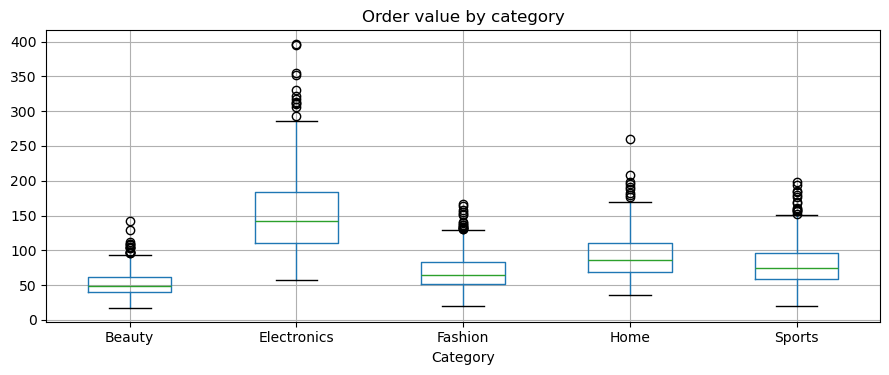

In [3]:
continuous = ['Order_Value','Discount_Pct','Delivery_Days','Recency_Days','Frequency','Customer_Rating']
display(descriptive_statistics(data, continuous).round(3))
statistics = run_hypothesis_tests(data)
for test_name, result in statistics.items(): print(test_name, result)
fig, axis = plt.subplots(figsize=(9, 4)); data.boxplot(column='Order_Value', by='Category', ax=axis); fig.suptitle(''); axis.set_title('Order value by category'); fig.tight_layout(); fig.savefig(FIGURES / 'statistics/category_anova_boxplot.png', dpi=150); plt.show()


## Section 2: Time Series Analysis and Forecasting

Dates are indexed and resampled to Monday-ending weeks; missing periods are forward-filled. ADF is run on levels and first differences. The ARIMA holdout forecast reports MAE, RMSE, MAPE and 95% confidence bands.

In [4]:
import joblib

weekly = prepare_weekly_sales(data)
print('ADF level:', adf_report(weekly))
print('ADF differenced:', adf_report(weekly.diff().dropna()))
save_decomposition(weekly, FIGURES / 'time_series/seasonal_decomposition.png')
forecast = forecast_sales(weekly, horizon=12, figure_path=FIGURES / 'time_series/arima_forecast_12weeks.png')
joblib.dump(forecast['model'], MODELS / 'arima_sales_model.pkl')
print('Forecast metrics:', forecast['metrics']); display(forecast['forecast'].to_frame('Forecast').round(2))


c:\Users\prajy\OneDrive\Desktop\work\apex_planet_dataAnalysis\task 4\apex-planet_task4\src\time_series.py:19: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag="AIC")
c:\Users\prajy\OneDrive\Desktop\work\apex_planet_dataAnalysis\task 4\apex-planet_task4\src\time_series.py:19: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adf

ADF level: {'statistic': -11.281881850173496, 'p_value': 1.4494095347002964e-20, 'critical_values': {'1%': -3.4942202045135513, '5%': -2.889485291005291, '10%': -2.5816762131519275}, 'stationary': True}
ADF differenced: {'statistic': -5.900323720774539, 'p_value': 2.78793738854e-07, 'critical_values': {'1%': -3.503514579651927, '5%': -2.893507960466837, '10%': -2.583823615311909}, 'stationary': True}
Forecast metrics: {'MAE': 551.5762599103226, 'RMSE': 647.474354596029, 'MAPE': 35.8268361519098}


,Forecast
2025-10-20,2244.70
2025-10-27,2216.91
2025-11-03,2218.51
2025-11-10,2218.42
2025-11-17,2218.42
2025-11-24,2218.42
2025-12-01,2218.42
2025-12-08,2218.42
2025-12-15,2218.42
2025-12-22,2218.42


## Section 3: Customer Segmentation

Customer-level RFM features are standardized, evaluated for k=2..8 using WCSS and silhouette scores, clustered with K-Means, and projected with PCA. Persona recommendations are printed from the profile table.

In [ ]:
rfm = build_rfm(data)
segmentation = fit_segmentation(rfm, FIGURES / 'clustering')
segmented = segmentation['rfm']; segmented.to_csv(ROOT / 'data/processed/rfm_segmented_customers.csv', index=False)
joblib.dump(segmentation['model'], MODELS / 'kmeans_rfm_model.pkl')
display(segmentation['profile']); print('Selected k:', segmentation['selected_k'])
for cluster, row in segmentation['profile'].iterrows(): print(f'Cluster {cluster}: recency={row.Recency:.1f}, frequency={row.Frequency:.1f}, monetary={row.Monetary:.1f}; tailor retention, win-back, or cross-sell actions.')


## Section 4: Predictive Modeling

Linear regression predicts Order_Value from Recency, Frequency, Discount_Pct, and Delivery_Days. Logistic regression and a constrained decision tree classify Churn. Confusion matrices, Accuracy, Precision, Recall, F1, ROC-AUC, coefficients, and limitations are included.

In [ ]:
predictive = run_predictive_models(data, FIGURES / 'predictive')
joblib.dump(predictive['regression']['model'], MODELS / 'linear_order_value_model.pkl')
joblib.dump(predictive['classification']['logistic']['model'], MODELS / 'logistic_churn_model.pkl')
joblib.dump(predictive['classification']['decision_tree']['model'], MODELS / 'decision_tree_churn.pkl')
print('Regression:', predictive['regression']['metrics'])
for name in ['logistic','decision_tree']:
    result = predictive['classification'][name]; print(name, {metric: result[metric] for metric in ['accuracy','precision','recall','f1','roc_auc']}); print(result['confusion_matrix'])


## Section 5: Deliverables and Documentation

README.md contains setup, layout, limitations, and a metric-filled LinkedIn completion post template. Model results are associations on synthetic data: validate temporal drift, leakage, calibration, class costs, and causal assumptions before deployment.

Completion post metrics can be copied from the cells above: forecast MAE/RMSE/MAPE, regression R², and best churn ROC-AUC.